## Problem Statement

### Business Context
An over-the-top (OTT) media service is a media service offered directly to viewers via the internet. The term is most synonymous with subscription-based video-on-demand services that offer access to film and television content, including existing series acquired from other producers, as well as original content produced specifically for the service. They are typically accessed via websites on personal computers, apps on smartphones and tablets, or televisions with integrated Smart TV platforms.

Presently, OTT services are at a relatively nascent stage and are widely accepted as a trending technology across the globe. With the increasing change in customers' social behavior, which is shifting from traditional subscriptions to broadcasting services and OTT on-demand video and music subscriptions every year, OTT streaming is expected to grow at a very fast pace. The global OTT market size was valued at $121.61 billion in 2019 and is projected to reach $1,039.03 billion by 2027, growing at a CAGR of 29.4% from 2020 to 2027. The shift from television to OTT services for entertainment is driven by benefits such as on-demand services, ease of access, and access to better networks and digital connectivity.

With the outbreak of COVID19, OTT services are striving to meet the growing entertainment appetite of viewers, with some platforms already experiencing a 46% increase in consumption and subscriber count as viewers seek fresh content. With innovations and advanced transformations, which will enable the customers to access everything they want in a single space, OTT platforms across the world are expected to increasingly attract subscribers on a concurrent basis.


### Objective

ShowTime is an OTT service provider and offers a wide variety of content (movies, web shows, etc.) for its users. They want to determine the driver variables for first-day content viewership so that they can take necessary measures to improve the viewership of the content on their platform. Some of the reasons for the decline in viewership of content would be the decline in the number of people coming to the platform, decreased marketing spend, content timing clashes, weekends and holidays, etc. They have hired you as a Data Scientist, shared the data of the current content in their platform, and asked you to analyze the data and come up with a linear regression model to determine the driving factors for first-day viewership.

### Data Description

1. visitors: Average number of visitors, in millions, to the platform in the past week
2. ad_impressions: Number of ad impressions, in millions, across all ad campaigns for the content (running and completed)
3. major_sports_event: Any major sports event on the day
4. genre: Genre of the content
5. dayofweek: Day of the release of the content
6. season: Season of the release of the content
7. views_trailer: Number of views, in millions, of the content trailer
8. views_content: Number of first-day views, in millions, of the content


## Importing necessary libraries

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

#to perform feature engineering
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

from scipy.stats import shapiro

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Loading the dataset

In [2]:
# loading data
data = pd.read_csv('/content/ottdata.csv') ## Complete the code to read the data

FileNotFoundError: [Errno 2] No such file or directory: '/content/ottdata.csv'

## Data Overview

### Displaying the first 5 rows of dataset

In [ ]:
data.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


### Displaying the last five rows of the dataset

In [ ]:
data.tail()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
995,1.58,1311.96,0,Romance,Friday,Fall,48.58,0.36
996,1.34,1329.48,0,Action,Friday,Summer,72.42,0.56
997,1.62,1359.80,1,Sci-Fi,Wednesday,Fall,150.44,0.66
998,2.06,1698.35,0,Romance,Monday,Summer,48.72,0.47
999,1.36,1140.23,0,Comedy,Saturday,Summer,52.94,0.49


### Displaying the shape of the dataset

In [ ]:
data.shape

(1000, 8)

### Displaying the Datatypes of the Columns

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


### Displaying the statistical Summary

In [ ]:
data.describe()

,visitors,ad_impressions,major_sports_event,views_trailer,views_content
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1.704290,1434.712290,0.400000,66.91559,0.473400
std,0.231973,289.534834,0.490143,35.00108,0.105914
min,1.250000,1010.870000,0.000000,30.08000,0.220000
25%,1.550000,1210.330000,0.000000,50.94750,0.400000
50%,1.700000,1383.580000,0.000000,53.96000,0.450000
75%,1.830000,1623.670000,1.000000,57.75500,0.520000
max,2.340000,2424.200000,1.000000,199.92000,0.890000


### Checking the missing values

In [ ]:
data.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


In [ ]:
data.duplicated().sum()

0

## Exploratory Data Analysis

### Univariate Analysis

#### Visitors

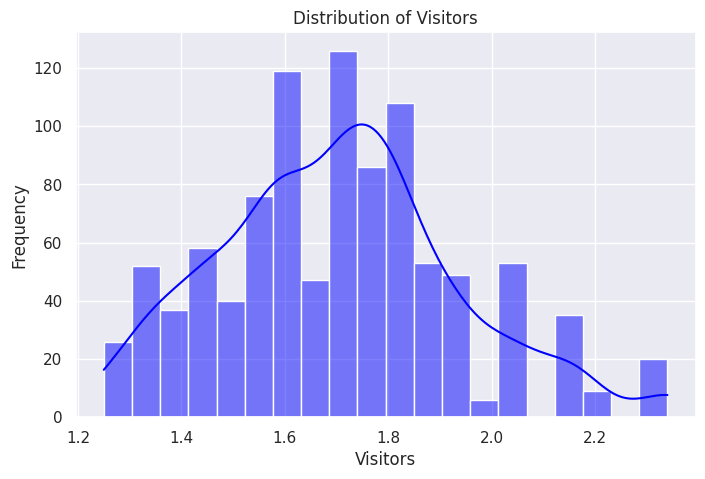

In [ ]:
# Univariate Analysis: Visitors
plt.figure(figsize=(8, 5))
sns.histplot(data['visitors'], kde=True, color="blue")
plt.title("Distribution of Visitors")
plt.xlabel("Visitors")
plt.ylabel("Frequency")
plt.show()


#### Ad Impressions

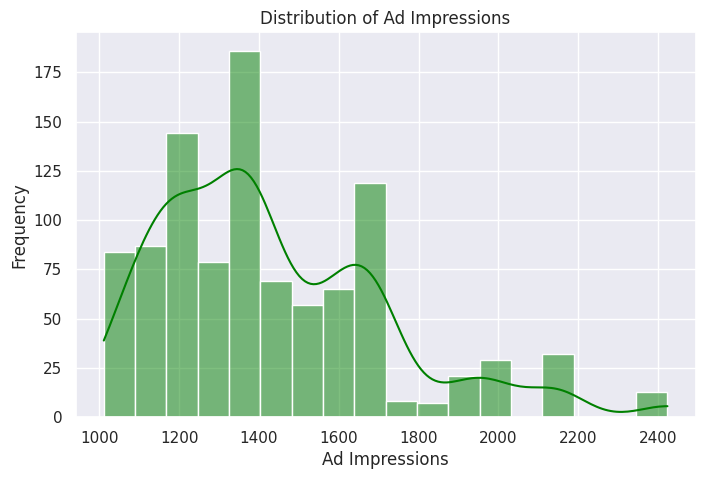

In [ ]:
# Univariate Analysis: Ad Impressions
plt.figure(figsize=(8, 5))
sns.histplot(data['ad_impressions'], kde=True, color="green")
plt.title("Distribution of Ad Impressions")
plt.xlabel("Ad Impressions")
plt.ylabel("Frequency")
plt.show()


#### Views Trailers

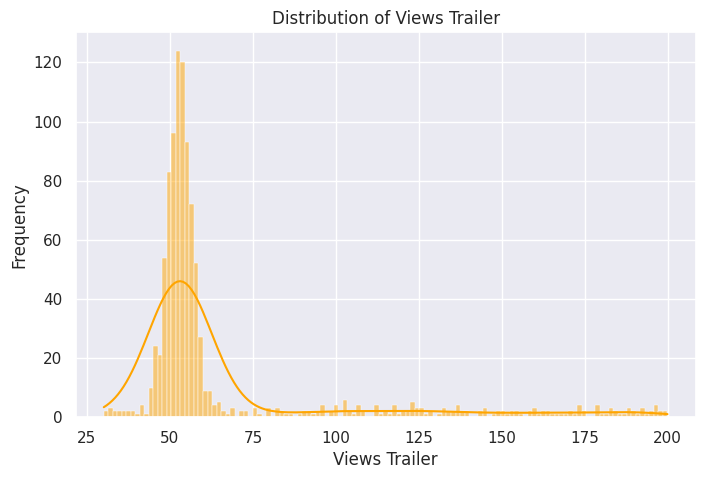

In [ ]:
# Univariate Analysis: Views Trailer
plt.figure(figsize=(8, 5))
sns.histplot(data['views_trailer'], kde=True, color="orange")
plt.title("Distribution of Views Trailer")
plt.xlabel("Views Trailer")
plt.ylabel("Frequency")
plt.show()


#### Views Content

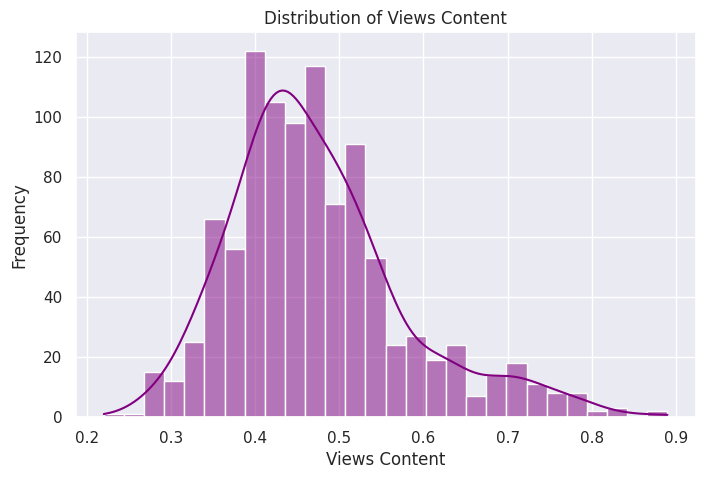

In [ ]:
# Univariate Analysis: Views Content
plt.figure(figsize=(8, 5))
sns.histplot(data['views_content'], kde=True, color="purple")
plt.title("Distribution of Views Content")
plt.xlabel("Views Content")
plt.ylabel("Frequency")
plt.show()


#### Genres

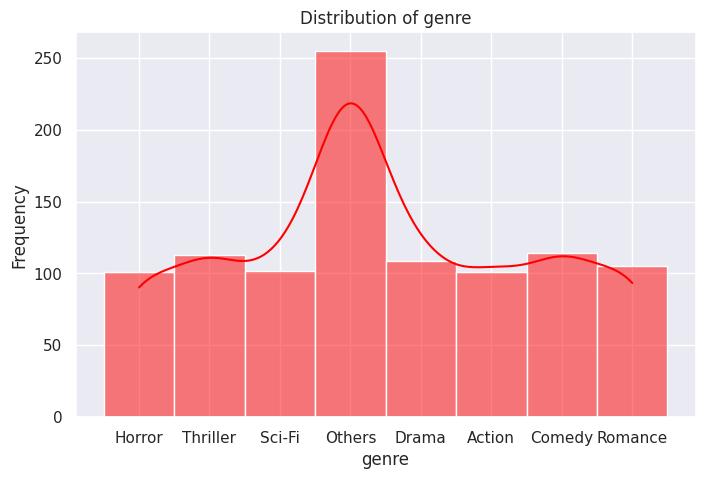

In [ ]:
# Univariate Analysis: Views Content
plt.figure(figsize=(8, 5))
sns.histplot(data['genre'], kde=True, color="red")
plt.title("Distribution of genre")
plt.xlabel("genre")
plt.ylabel("Frequency")
plt.show()


### Bivariate Analysis

#### Correlation Heatmap

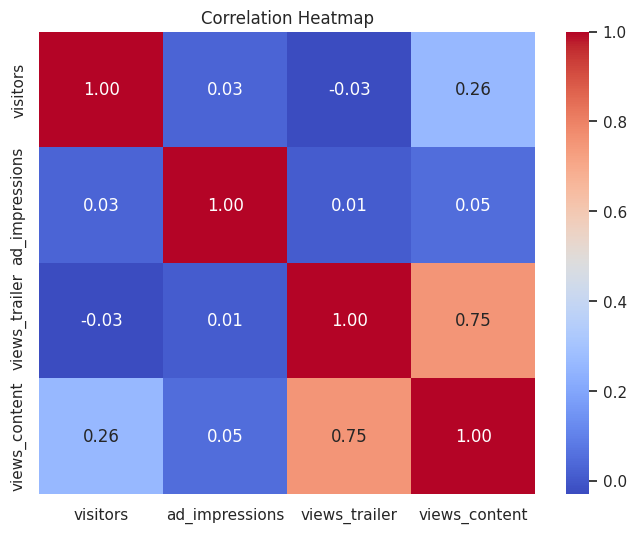

In [ ]:
# Bivariate Analysis: Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = data[['visitors', 'ad_impressions', 'views_trailer', 'views_content']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()


#### 1. Visitors vs All Other Variables

<ipython-input-16-276285f963d8>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genre', y='visitors', data=data, palette="coolwarm")


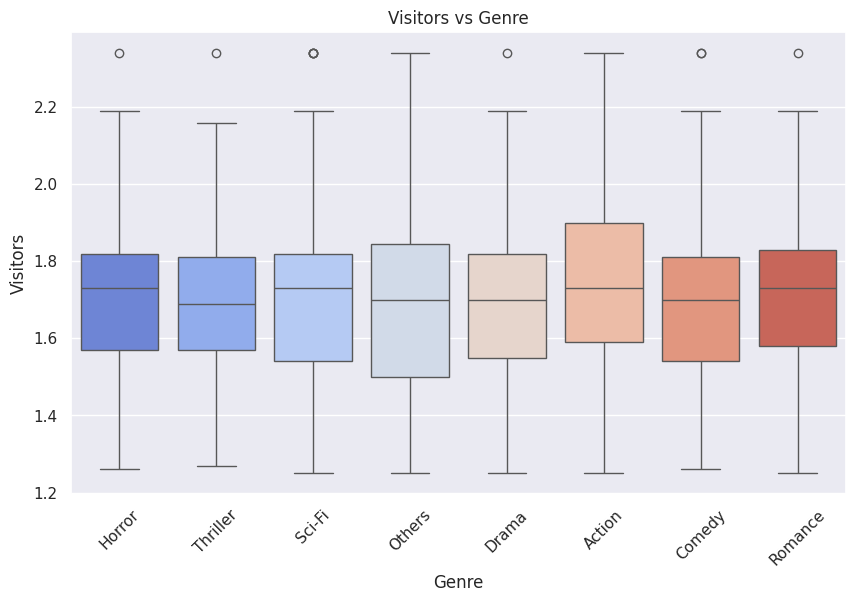

In [ ]:
# Visitors vs Genre
plt.figure(figsize=(10, 6))
sns.boxplot(x='genre', y='visitors', data=data, palette="coolwarm")
plt.title("Visitors vs Genre")
plt.xlabel("Genre")
plt.ylabel("Visitors")
plt.xticks(rotation=45)
plt.show()

#### Outlier Treatment

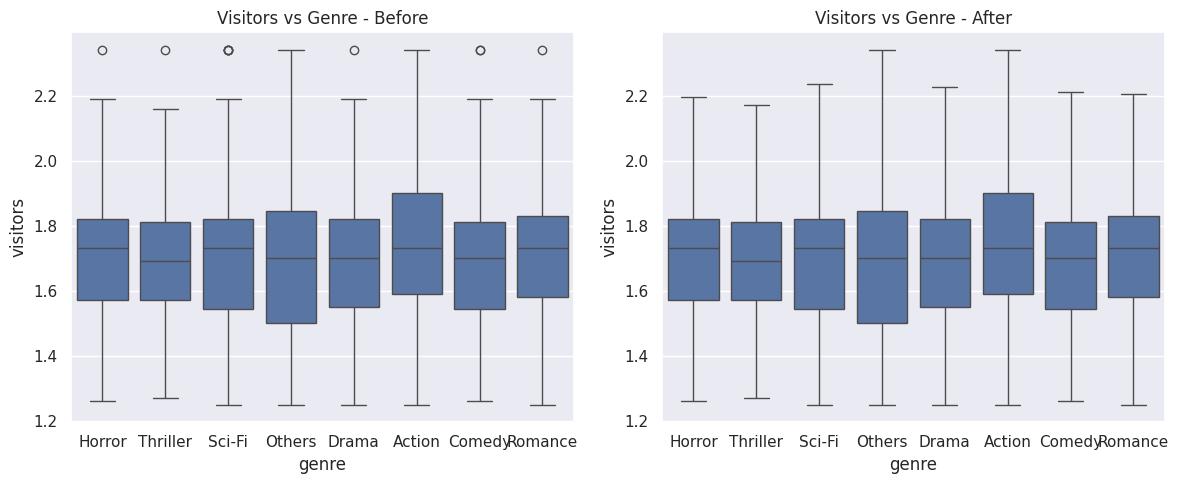

In [ ]:
def treat_outliers(df, col, group_col):
    """
    Simple outlier treatment using IQR method
    """
    df_clean = df.copy()

    # Calculate bounds for each group
    grouped = df_clean.groupby(group_col)[col]
    Q1 = grouped.transform('quantile', 0.25)
    Q3 = grouped.transform('quantile', 0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Replace outliers with bounds
    df_clean.loc[df_clean[col] < lower, col] = lower
    df_clean.loc[df_clean[col] > upper, col] = upper

    return df_clean

def plot_comparison(df, df_clean, col, group_col, title):
    """
    Plot before and after boxplots
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(data=df, x=group_col, y=col, ax=ax1).set_title(f'{title} - Before')
    sns.boxplot(data=df_clean, x=group_col, y=col, ax=ax2).set_title(f'{title} - After')
    plt.tight_layout()
    plt.show()

# Clean and plot for genre
genre_clean = treat_outliers(data, 'visitors', 'genre')
plot_comparison(data, genre_clean, 'visitors', 'genre', 'Visitors vs Genre')


<ipython-input-18-348b7c8475cf>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dayofweek', y='visitors', data=data, palette="Set2")


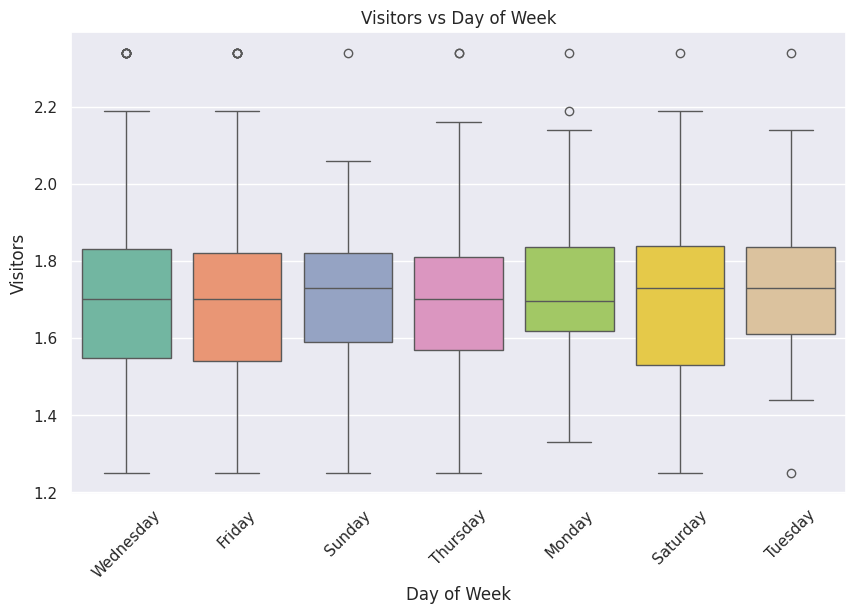

In [ ]:
# Visitors vs Day of Week
plt.figure(figsize=(10, 6))
sns.boxplot(x='dayofweek', y='visitors', data=data, palette="Set2")
plt.title("Visitors vs Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Visitors")
plt.xticks(rotation=45)
plt.show()

#### Outlier Treatment

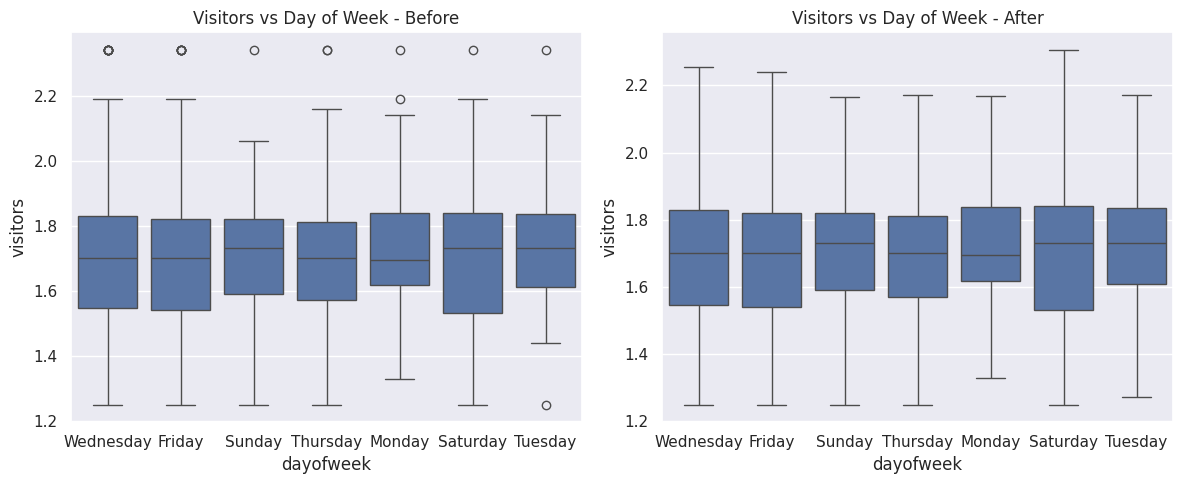

In [ ]:
def treat_outliers(df, col, group_col):
    """
    Simple outlier treatment using IQR method
    """
    df_clean = df.copy()

    # Calculate bounds for each group
    grouped = df_clean.groupby(group_col)[col]
    Q1 = grouped.transform('quantile', 0.25)
    Q3 = grouped.transform('quantile', 0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Replace outliers with bounds
    df_clean.loc[df_clean[col] < lower, col] = lower
    df_clean.loc[df_clean[col] > upper, col] = upper

    return df_clean

def plot_comparison(df, df_clean, col, group_col, title):
    """
    Plot before and after boxplots
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(data=df, x=group_col, y=col, ax=ax1).set_title(f'{title} - Before')
    sns.boxplot(data=df_clean, x=group_col, y=col, ax=ax2).set_title(f'{title} - After')
    plt.tight_layout()
    plt.show()

    # Clean and plot for day of week
dow_clean = treat_outliers(data, 'visitors', 'dayofweek')
plot_comparison(data, dow_clean, 'visitors', 'dayofweek', 'Visitors vs Day of Week')

<ipython-input-20-ea7fb605287c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='visitors', data=data, palette="Set3")


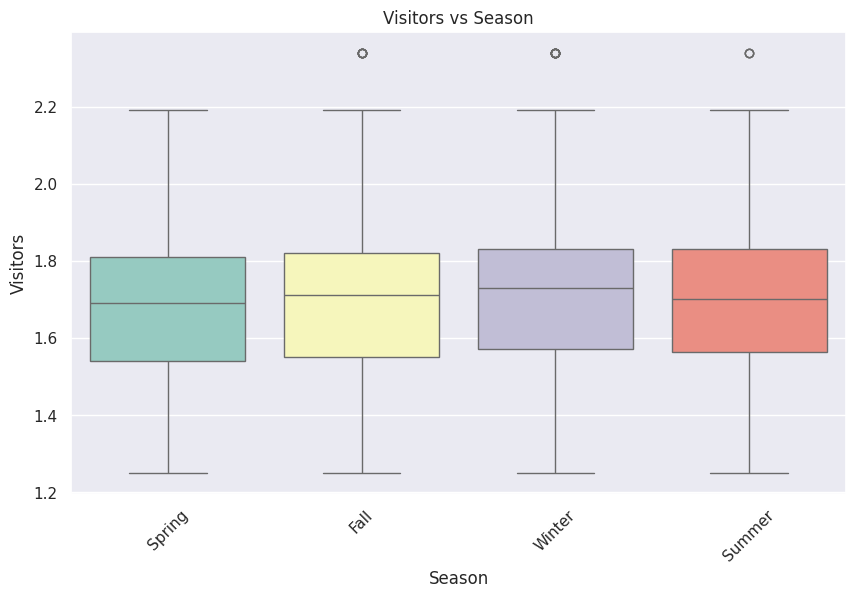

In [ ]:
# Visitors vs Season
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='visitors', data=data, palette="Set3")
plt.title("Visitors vs Season")
plt.xlabel("Season")
plt.ylabel("Visitors")
plt.xticks(rotation=45)
plt.show()

#### Outlier Treatment

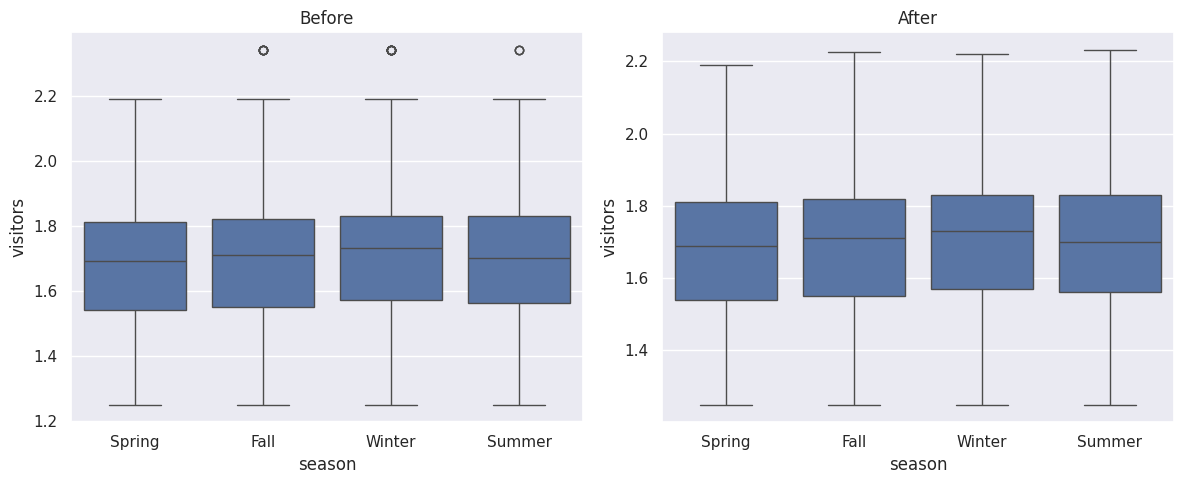

In [ ]:
def treat_outliers(df, col, group_col):
    """
    Simple outlier treatment using IQR method
    """
    df_clean = df.copy()

    # Calculate bounds for each group
    grouped = df_clean.groupby(group_col)[col]
    Q1 = grouped.transform('quantile', 0.25)
    Q3 = grouped.transform('quantile', 0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Replace outliers with bounds
    df_clean.loc[df_clean[col] < lower, col] = lower
    df_clean.loc[df_clean[col] > upper, col] = upper

    return df_clean

# Treat outliers and plot
data_clean = treat_outliers(data, 'visitors', 'season')

# Compare before/after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=data, x='season', y='visitors', ax=ax1).set_title('Before')
sns.boxplot(data=data_clean, x='season', y='visitors', ax=ax2).set_title('After')
plt.tight_layout()
plt.show()

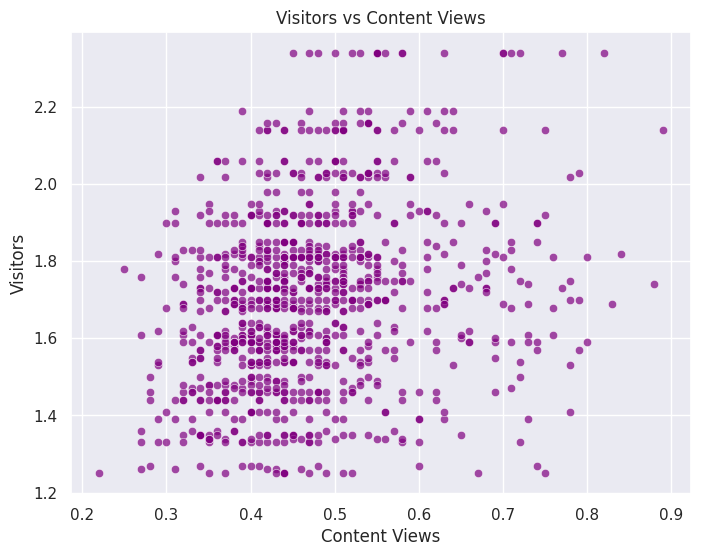

In [ ]:
# Visitors vs Views Content
plt.figure(figsize=(8, 6))
sns.scatterplot(x='views_content', y='visitors', data=data, color='purple', alpha=0.7)
plt.title("Visitors vs Content Views")
plt.xlabel("Content Views")
plt.ylabel("Visitors")
plt.show()

#### 2. Views Content vs Other Variables

<ipython-input-23-8381b7763c4d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dayofweek', y='views_content', data=data, palette="Set1")


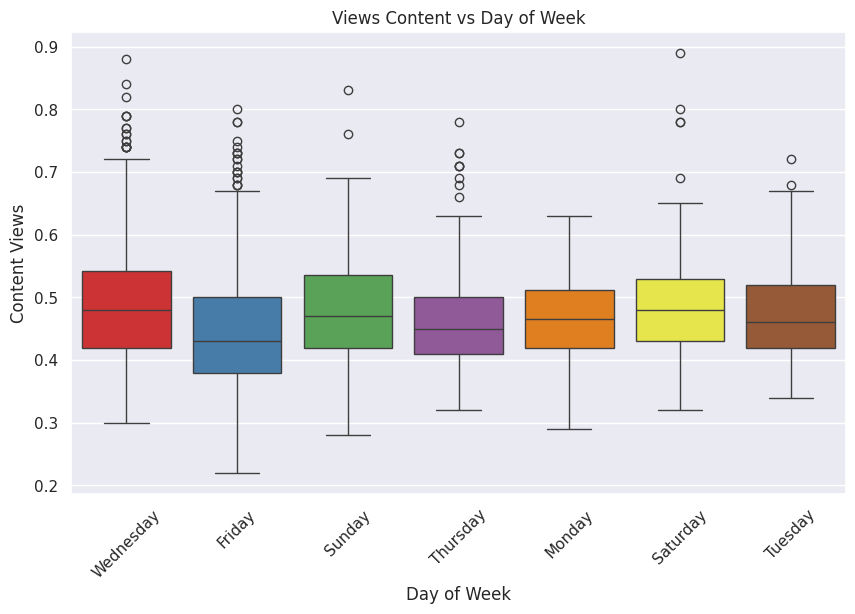

In [ ]:
# Views Content vs Day of Week
plt.figure(figsize=(10, 6))
sns.boxplot(x='dayofweek', y='views_content', data=data, palette="Set1")
plt.title("Views Content vs Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Content Views")
plt.xticks(rotation=45)
plt.show()

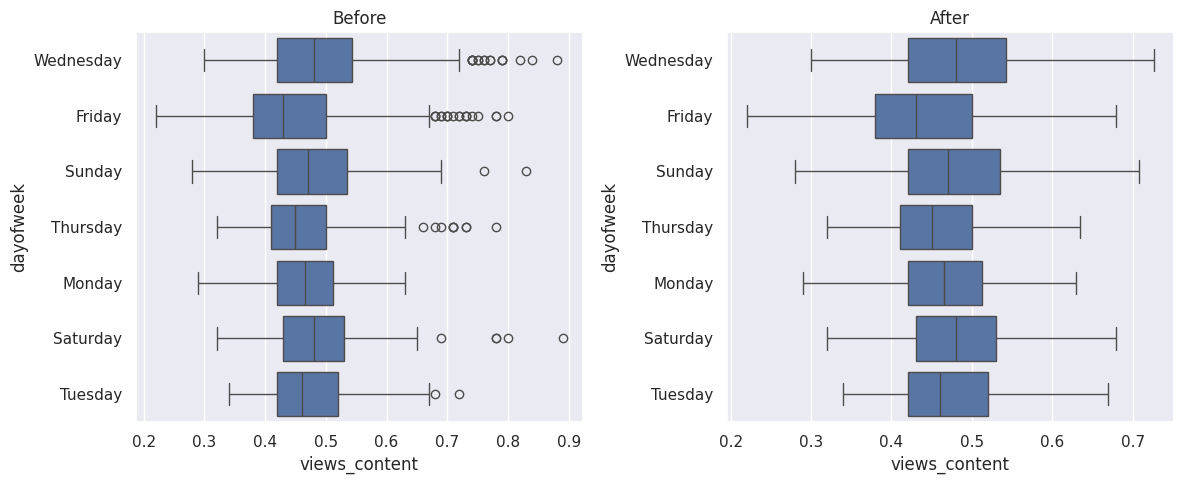

In [ ]:
def treat_outliers(df, col, group_col):
    """
    Simple outlier treatment using IQR method
    """
    df_clean = df.copy()

    # Calculate bounds for each group
    grouped = df_clean.groupby(group_col)[col]
    Q1 = grouped.transform('quantile', 0.25)
    Q3 = grouped.transform('quantile', 0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Replace outliers with bounds
    df_clean.loc[df_clean[col] < lower, col] = lower
    df_clean.loc[df_clean[col] > upper, col] = upper

    return df_clean

# Treat outliers and plot
data_clean = treat_outliers(data, 'views_content', 'dayofweek')

# Compare before/after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=data, x='views_content', y='dayofweek', ax=ax1).set_title('Before')
sns.boxplot(data=data_clean, x='views_content', y='dayofweek', ax=ax2).set_title('After')
plt.tight_layout()
plt.show()

<ipython-input-25-46932409586e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='views_content', data=data, palette="Set2")


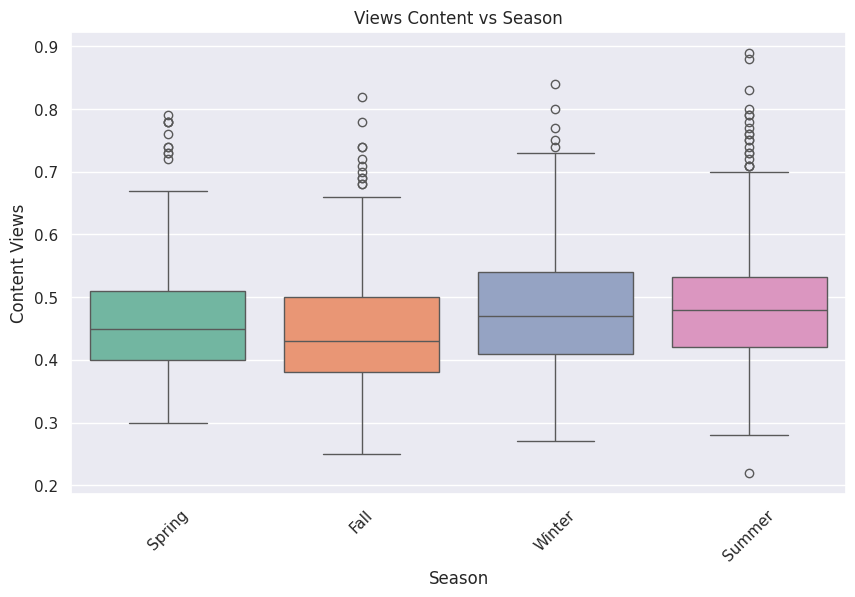

In [ ]:
# Views Content vs Season
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='views_content', data=data, palette="Set2")
plt.title("Views Content vs Season")
plt.xlabel("Season")
plt.ylabel("Content Views")
plt.xticks(rotation=45)
plt.show()


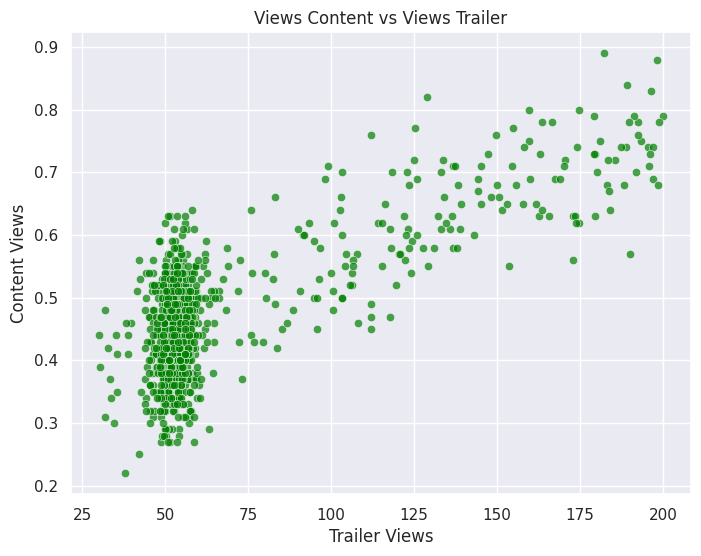

In [ ]:
# Views Content vs Views Trailer
plt.figure(figsize=(8, 6))
sns.scatterplot(x='views_trailer', y='views_content', data=data, color='green', alpha=0.7)
plt.title("Views Content vs Views Trailer")
plt.xlabel("Trailer Views")
plt.ylabel("Content Views")
plt.show()

<ipython-input-27-27d61c9f7228>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genre', y='views_content', data=data, palette="coolwarm")


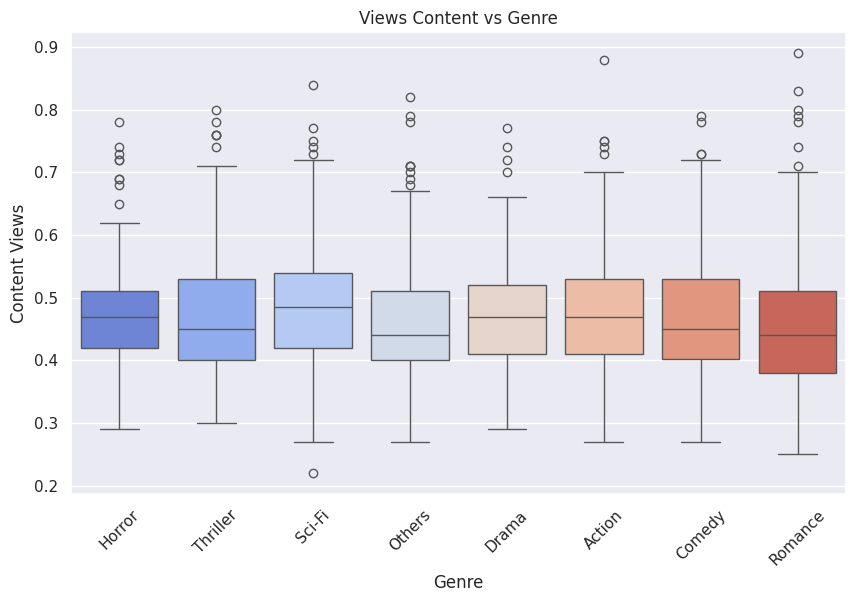

In [ ]:
# Views Content vs Genre
plt.figure(figsize=(10, 6))
sns.boxplot(x='genre', y='views_content', data=data, palette="coolwarm")
plt.title("Views Content vs Genre")
plt.xlabel("Genre")
plt.ylabel("Content Views")
plt.xticks(rotation=45)
plt.show()

#### 3. Ad Impressions

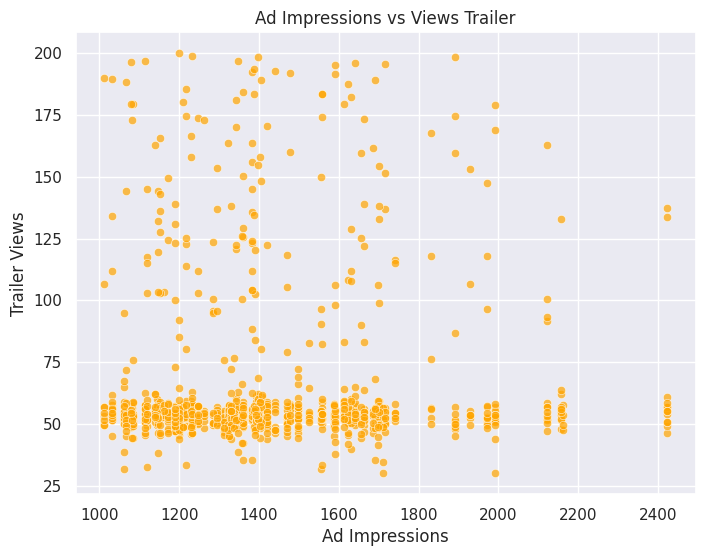

In [ ]:
#Ad Impressions vs Views Trailer
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ad_impressions', y='views_trailer', data=data, color='orange', alpha=0.7)
plt.title("Ad Impressions vs Views Trailer")
plt.xlabel("Ad Impressions")
plt.ylabel("Trailer Views")
plt.show()

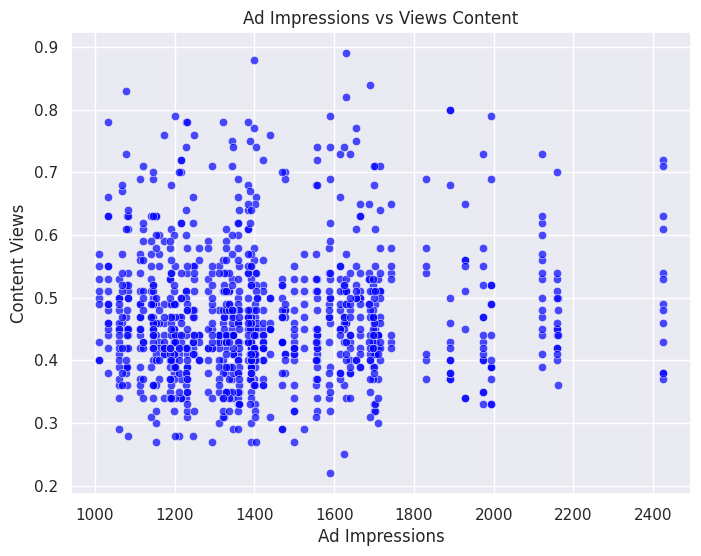

In [ ]:
# Ad Impressions vs Views Content
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ad_impressions', y='views_content', data=data, color='blue', alpha=0.7)
plt.title("Ad Impressions vs Views Content")
plt.xlabel("Ad Impressions")
plt.ylabel("Content Views")
plt.show()

### Feature Engineering

In [ ]:
def engineer_features(data):
    df = data.copy()

    # Step 1: Encoding Categorical Variables
    genre_encoded = pd.get_dummies(df['genre'], prefix='genre', drop_first=True)

    df['dayofweek_num'] = pd.Categorical(df['dayofweek']).codes
    df['season_num'] = pd.Categorical(df['season']).codes

    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek_num'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek_num'] / 7)
    df['season_sin'] = np.sin(2 * np.pi * df['season_num'] / 4)
    df['season_cos'] = np.cos(2 * np.pi * df['season_num'] / 4)

    # Step 2: Transform Numerical Variables
    df['log_ad_impressions'] = np.log1p(df['ad_impressions'])
    df['log_views_content'] = np.log1p(df['views_content'])
    df['log_views_trailer'] = np.log1p(df['views_trailer'])

    # Step 3: Create Interaction Features
    df['interaction_views_day'] = df['views_content'] * df['dayofweek_num']
    df['interaction_views_genre'] = df['views_content'] * pd.Categorical(df['genre']).codes

    # Step 4: Generate Derived Features
    epsilon = 1e-10
    df['engagement_per_visitor'] = df['views_content'] / (df['visitors'] + epsilon)
    df['conversion_trailer_to_content'] = df['views_content'] - df['views_trailer']

    # Merge one-hot encoded genre
    df = pd.concat([df, genre_encoded], axis=1)

    # Define numerical features for scaling
    numerical_features = [
        'visitors', 'views_content', 'views_trailer', 'ad_impressions',
        'log_ad_impressions', 'log_views_content', 'log_views_trailer',
        'interaction_views_day', 'interaction_views_genre',
        'engagement_per_visitor', 'conversion_trailer_to_content'
    ]

    # Scale numerical features
    scaler = StandardScaler()
    df[numerical_features] = scaler.fit_transform(df[numerical_features])

    return df

# Main execution
try:
    processed_data = engineer_features(data)
    print("\nFeature engineering successful!")
    print("\nProcessed features:")
    print(processed_data.columns.tolist())
    print("\nSample of processed data:")
    print(processed_data.head())

except Exception as e:
    print(f"Error during feature engineering: {str(e)}")


Feature engineering successful!

Processed features:
['visitors', 'ad_impressions', 'major_sports_event', 'genre', 'dayofweek', 'season', 'views_trailer', 'views_content', 'dayofweek_num', 'season_num', 'dayofweek_sin', 'dayofweek_cos', 'season_sin', 'season_cos', 'log_ad_impressions', 'log_views_content', 'log_views_trailer', 'interaction_views_day', 'interaction_views_genre', 'engagement_per_visitor', 'conversion_trailer_to_content', 'genre_Comedy', 'genre_Drama', 'genre_Horror', 'genre_Others', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller']

Sample of processed data:
   visitors  ad_impressions  major_sports_event     genre  dayofweek  season  \
0 -0.147893       -1.108892                   0    Horror  Wednesday  Spring   
1 -1.053623        0.220110                   1  Thriller     Friday    Fall   
2 -1.010493       -1.228523                   1  Thriller  Wednesday    Fall   
3  0.628448       -0.317711                   1    Sci-Fi     Friday    Fall   
4 -1.053623       

### Model Building

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = data.drop(columns=['views_content'])  # Features
y = data['views_content']  # Target

# First, identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Create pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the pipeline
model_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = model_pipeline.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Get feature names after encoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_features])

# Get coefficients
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_pipeline.named_steps['regressor'].coef_
}).sort_values(by='Coefficient', ascending=False)

# Print results
print("Model Performance:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}\n")
print("Model Coefficients:")
print(coefficients)

Model Performance:
Mean Squared Error: 0.0025
R^2 Score: 0.7743

Model Coefficients:
                Feature  Coefficient
0              visitors     0.128909
12   dayofweek_Saturday     0.052561
16  dayofweek_Wednesday     0.049532
11     dayofweek_Monday     0.045065
18        season_Summer     0.044605
13     dayofweek_Sunday     0.038818
15    dayofweek_Tuesday     0.032412
19        season_Winter     0.026532
17        season_Spring     0.023201
14   dayofweek_Thursday     0.019637
10       genre_Thriller     0.011518
5           genre_Drama     0.010636
9          genre_Sci-Fi     0.010008
6          genre_Horror     0.009434
7          genre_Others     0.004984
4          genre_Comedy     0.004389
3         views_trailer     0.002311
1        ad_impressions     0.000008
8         genre_Romance    -0.001385
2    major_sports_event    -0.059559


### Testing Assumptions Of Linear Regression Model

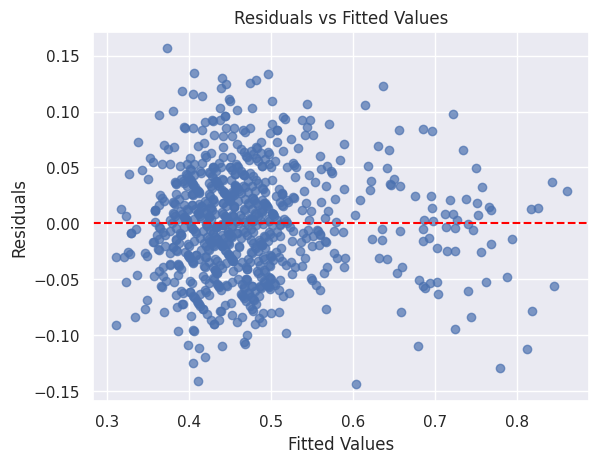

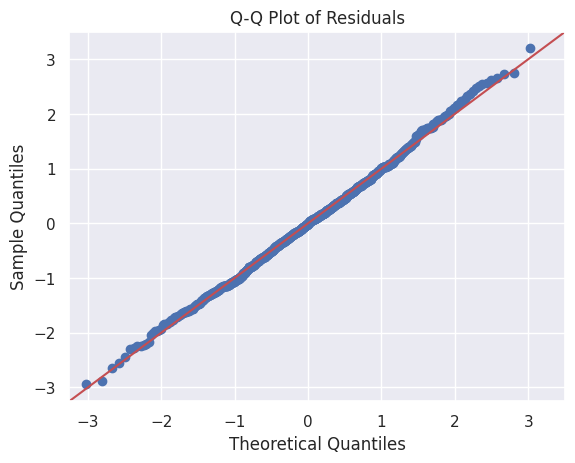

Shapiro-Wilk Test: Test Statistic = 0.9979, p-value = 0.4379
Residuals appear to be normally distributed.

Variance Inflation Factor (VIF):
                Feature        VIF
0              visitors  26.065912
1        ad_impressions  19.731307
2    major_sports_event   1.742907
3         views_trailer   4.511708
4          genre_Comedy   1.939941
5           genre_Drama   2.068384
6          genre_Horror   2.037733
7          genre_Others   3.261380
8         genre_Romance   2.038509
9          genre_Sci-Fi   1.937147
10       genre_Thriller   2.010787
11     dayofweek_Monday   1.076586
12   dayofweek_Saturday   1.228074
13     dayofweek_Sunday   1.202715
14   dayofweek_Thursday   1.281478
15    dayofweek_Tuesday   1.084141
16  dayofweek_Wednesday   1.897971
17        season_Spring   2.011645
18        season_Summer   2.001957
19        season_Winter   2.088696


In [ ]:
# Get residuals and fitted values
y_train_pred = model_pipeline.predict(X_train)
residuals = y_train - y_train_pred

# 1. Linearity and Homoscedasticity: Residuals vs Fitted Values Plot
plt.scatter(y_train_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

# 2. Normality of Residuals: Q-Q Plot
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

# 3. Normality Test: Shapiro-Wilk Test
stat, p_value = shapiro(residuals)
print(f"Shapiro-Wilk Test: Test Statistic = {stat:.4f}, p-value = {p_value:.4f}")
if p_value > 0.05:
    print("Residuals appear to be normally distributed.\n")
else:
    print("Residuals are not normally distributed.\n")

# 4. Multicollinearity: Variance Inflation Factor (VIF)
X_transformed = preprocessor.fit_transform(X_train)
vif_data = pd.DataFrame({
    'Feature': feature_names,
    'VIF': [variance_inflation_factor(X_transformed, i) for i in range(X_transformed.shape[1])]
})
print("Variance Inflation Factor (VIF):")
print(vif_data)


### Model Performance Evaluation Based On Different Metrics

In [ ]:


# Predictions for train and test sets
y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

# Calculate metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

rmse_train = mse_train**0.5
rmse_test = mse_test**0.5

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Adjusted R-squared calculation for test set
n = X_test.shape[0]
k = X_test.shape[1]
adjusted_r2_test = 1 - ((1 - r2_test) * (n - 1) / (n - k - 1))

# Display results
print("Model Performance Metrics:")

print(f"Train Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae_test:.4f}\n")

print(f"Train Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Test Mean Squared Error (MSE): {mse_test:.4f}\n")

print(f"Train Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"Test Root Mean Squared Error (RMSE): {rmse_test:.4f}\n")

print(f"Train R^2 Score: {r2_train:.4f}")
print(f"Test R^2 Score: {r2_test:.4f}\n")

print(f"Adjusted R^2 for Test Set: {adjusted_r2_test:.4f}")


Model Performance Metrics:
Train Mean Absolute Error (MAE): 0.0389
Test Mean Absolute Error (MAE): 0.0399

Train Mean Squared Error (MSE): 0.0024
Test Mean Squared Error (MSE): 0.0025

Train Root Mean Squared Error (RMSE): 0.0489
Test Root Mean Squared Error (RMSE): 0.0500

Train R^2 Score: 0.7868
Test R^2 Score: 0.7743

Adjusted R^2 for Test Set: 0.7661
